# Imma Hungry (CIS 1921 Project)

Harry Li, Nabo Yu

We want to build an optimizer for the [Share Food Program](https://www.sharefoodprogram.org/philly-food-rescue).

In brief, the problem is as follows. We have a network of volunteer drivers to pick up perishable food from grocers, restaurants, and caterers, and they deliver them to affordable housing communities and nonprofits.

### Data Source

We use real world data from [Datasets - OpenDataPhilly](https://opendataphilly.org/datasets/?category=food), including [OpenMaps - OpenDataPhilly](https://opendataphilly.org/datasets/openmaps/) and [Free Food & Meal Sites - OpenDataPhilly](https://opendataphilly.org/datasets/free-meals/), and Google Maps API, including the [Compute Route Matrix](https://developers.google.com/maps/documentation/routes/compute-route-matrix-over) API.

- The OpenMaps dataset provides the geographic information of Philly.
- The Free Food & Meal Sites dataset provides the food donations information in Philly.
- The Compute Route Matrix API provides the travel route matrix (i.e., generalized distance matrix taking route and traffic into consideration) between the locations.

### Formulation

Let there be $X$ volunteer drivers with carrying capacity $c$ scattered around Philadelphia, $Y$ active food donors with $s$ hours of spoilage windows, and $Z$ drop-off locations with pantry capacity $p$. We will optimize the driver-donation assignments and the route for each assignment by minimizing *food waste* and maximizing *nutrient availability* in the process.

### Evaluation

We evaluate the system by running simulations of sampled location subsets in the OpenDataPhilly dataset.

1. With small-scale driver and location samples to verify our pipeline works.
2. With larger-scale driver and location samples to compare our solver with
   - a baseline greedy strategy, and
   - some heuristic strategy
   
   to see if our solver does indeed improve upon naive approaches.

## Data Source

In [1]:
import polars as pl

print("OK!")

OK!


In [2]:
def fetch_data(remote: str, local: str):
    import os

    if os.path.exists(local):
        return
    os.makedirs(os.path.dirname(local), exist_ok=True)
    import urllib.request

    urllib.request.urlretrieve(remote, local)

There is no public information on food donors. We use the information of restaurants instead, assuming they are willing to donate food.

In [3]:
# https://opendataphilly.org/datasets/licenses-and-inspections-business-licenses/
fetch_data(
    "https://phl.carto.com/api/v2/sql?q=SELECT+*,+ST_Y(the_geom)+AS+lat,+ST_X(the_geom)+AS+lng+FROM+business_licenses&filename=business_licenses&format=csv&skipfields=cartodb_id",
    "data/business_licenses.csv",
)

donor_locations = pl.read_csv("data/business_licenses.csv", infer_schema_length=65536)

donor_locations = (
    donor_locations.filter(
        pl.col("licensestatus") == "Active",
        pl.col("licensetype").is_in(
            [
                "Food Preparing and Serving",
                "Food Preparing and Serving (30+)",
                "Food Establishment, Retail Permanent",
            ]
        ),
    )
    .select(
        pl.col("business_name"),
        pl.col("address"),
        pl.col("lat"),
        pl.col("lng"),
    )
    .drop_nulls(subset=["lat", "lng"])
)

donor_locations = donor_locations.sample(50, seed=1921)
donor_locations

business_name,address,lat,lng
str,str,f64,f64
"""Espinal 1 Groocery Inc.""","""1854 HART LN""",39.990777,-75.120822
"""LIM THACH (L & S LAUNDRY)""","""1536 S 5TH ST""",39.928688,-75.153939
"""ALAN SUPERMARKET INC""","""1245 POINT BREEZE AVE""",39.936307,-75.177567
"""A & A GROCERY STORE CORP""","""2000 N GRATZ ST""",39.984271,-75.164429
"""MAMA SHAN'S AFRICAN & SOUL FOO…","""2957 N 22ND ST""",39.999959,-75.166394
…,…,…,…
"""MA EXPLORERS DEN INC_""","""2160 W OLNEY AVE""",40.041048,-75.157919
"""REYES GROCERY (REYES GROCERY)""","""924 S 20TH ST""",39.940368,-75.176243
"""SCHAAF FOOD INCORPORATED""","""3301 SAINT VINCENT ST""",40.037987,-75.047083


We use the information of existing share food program sites.

In [4]:
# https://opendataphilly.org/datasets/free-meals/
# spatialRefId=4326 gives WGS84 lat/lng directly in x (lng) and y (lat) columns
fetch_data(
    "https://hub.arcgis.com/api/v3/datasets/5825a32bb8844bb097f7a16d4fbf4f23_0/downloads/data?format=csv&spatialRefId=4326&where=1%3D1",
    "data/free_meal_sites.csv",
)

dropoff_locations = pl.read_csv("data/free_meal_sites.csv")

dropoff_locations = (
    dropoff_locations.filter(pl.col("category").str.contains("SHARE FOOD PROGRAM"))
    .select(
        pl.col("site_name"),
        pl.col("address"),
        pl.col("x").alias("lng"),
        pl.col("y").alias("lat"),
    )
    .drop_nulls(subset=["lat", "lng"])
)

dropoff_locations = dropoff_locations.sample(14, seed=1921)
dropoff_locations

site_name,address,lng,lat
str,str,f64,f64
"""New Hope AME Zion Church""","""5802 Musgrave St.""",-75.16892,40.044004
"""Resurrection Community Church""","""6200 Dicks Ave""",-75.223919,39.922242
"""Reconciliation And Liberty Bib…","""6027 Chestnut St""",-75.241988,39.960755
"""North Philadelphia SDA Church""","""1510 W Oxford St""",-75.161137,39.977514
"""Interfaith Food Cupboard""","""3600 Baring St""",-75.19418,39.960881
…,…,…,…
"""Second Antioch Baptist Church""","""912 N 41st St""",-75.206079,39.970802
"""MAP Holistic CDC (Mankind Agai…","""1510 W Stiles St""",-75.161499,39.972554
"""Church of Pentecost""","""2530 Wharton St""",-75.186924,39.936495


We use the [OSRM Table API](http://router.project-osrm.org) (free, no key, OpenStreetMap-based) to compute driving distances and durations for all (donor + drop-off) → drop-off pairs in a single request.

Before querying, we filter pairs by **crow-flies (Haversine) distance**: pairs exceeding `MAX_CROW_FLIES_KM` are excluded from the output and treated as infeasible by the optimizer. This doesn't reduce OSRM calls (the table service always computes the full matrix), but it shrinks the optimizer's search space. If you later switch to the Google Maps Route Matrix API, the same filter will also skip billable elements.

**On duration and time-of-day**: OSRM uses static average speeds (no live traffic). For a planning/simulation context this is fine. If you need traffic-aware durations, switch to the Google Maps Routes API — the $200/month free credit covers ~10,000 route elements and should be sufficient for the project.

In [5]:
import os
import numpy as np

# Set to "osrm" for free routing (no API key, uses OpenStreetMap data, no live traffic)
# Set to "google" for traffic-aware routing (requires GOOGLE_MAPS_API_KEY env var or ~/.gcp_api_key)
ROUTING_BACKEND = "osrm"


def _load_google_api_key():
    key = os.environ.get("GOOGLE_MAPS_API_KEY", "")
    if not key:
        keyfile = os.path.expanduser("~/.gcp_api_key")
        if os.path.exists(keyfile):
            with open(keyfile) as f:
                key = f.read().strip()
    return key


GOOGLE_API_KEY = _load_google_api_key()

# Pairs with crow-flies distance beyond this are treated as infeasible by the optimizer.
# ~10 km keeps routes within a reasonable volunteer driving range in Philly (~6 miles).
# For the Google backend this also skips those elements from the API request (saves cost).
MAX_CROW_FLIES_KM = 10.0

# Sentinel used in distance/duration matrices for non-viable or unreachable pairs.
# Large enough that no optimizer will select these edges; small enough to avoid int32 overflow when summed.
INFEASIBLE = 10**7  # ~10,000 km / ~115 days — clearly unreachable
# Turns out this still causes overflow; we'll deal with it later on


def haversine_matrix(lat1, lng1, lat2, lng2):
    """Returns (m, n) matrix of crow-flies distances in km."""
    lat1 = np.radians(np.asarray(lat1, dtype=float))[:, None]
    lng1 = np.radians(np.asarray(lng1, dtype=float))[:, None]
    lat2 = np.radians(np.asarray(lat2, dtype=float))[None, :]
    lng2 = np.radians(np.asarray(lng2, dtype=float))[None, :]
    dlat, dlng = lat2 - lat1, lng2 - lng1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlng / 2) ** 2
    return 6371.0 * 2 * np.arcsin(np.sqrt(a.clip(0, 1)))


def _fetch_osrm(n_donors, n_dropoffs, all_lat, all_lng):
    """Returns (durations_s, distances_m) as (n_total, n_dropoffs) float arrays. NaN = unreachable."""
    import json, urllib.request

    n_total = n_donors + n_dropoffs
    coords = ";".join(f"{lng},{lat}" for lat, lng in zip(all_lat, all_lng))
    src_idx = ";".join(str(i) for i in range(n_total))
    dst_idx = ";".join(str(i) for i in range(n_total))
    url = (
        f"http://router.project-osrm.org/table/v1/driving/{coords}"
        f"?sources={src_idx}&destinations={dst_idx}"
        f"&annotations=duration,distance&generate_hints=false"
    )
    with urllib.request.urlopen(url, timeout=60) as resp:
        data = json.loads(resp.read())
    return (
        np.array(data["durations"], dtype=float),  # (n_total, n_dropoffs)
        np.array(data["distances"], dtype=float),  # (n_total, n_dropoffs)
    )


def _fetch_google(viable, n_donors, n_dropoffs, all_addresses):
    """Returns (durations_s, distances_m) as (n_total, n_dropoffs) float arrays. NaN = unreachable."""
    from google.api_core.client_options import ClientOptions
    import google.maps.routing_v2 as routes_api

    client = routes_api.RoutesClient(
        client_options=ClientOptions(api_key=GOOGLE_API_KEY)
    )
    n_total = n_donors + n_dropoffs

    all_origins = [
        routes_api.RouteMatrixOrigin(
            waypoint=routes_api.Waypoint(address=all_addresses[i])
        )
        for i in range(n_total)
    ]
    all_destinations = [
        routes_api.RouteMatrixDestination(waypoint=routes_api.Waypoint(address=all_addresses[i]))
        for i in range(n_total)
    ]

    # Skip origins with no viable destinations, saves billable API elements
    viable_origins = [i for i in range(n_total) if viable[i].any()]
    if skipped := n_total - len(viable_origins):
        print(f"  Skipping {skipped} origins with no viable destinations")

    durations = np.full((n_total, n_total), np.nan)
    distances = np.full((n_total, n_total), np.nan)

    BATCH_SIZE = 50 - n_dropoffs  # origins + destinations <= 50 per request
    for start in range(0, len(viable_origins), BATCH_SIZE):
        batch_indices = viable_origins[start : start + BATCH_SIZE]
        response = client.compute_route_matrix(
            routes_api.ComputeRouteMatrixRequest(
                origins=[all_origins[i] for i in batch_indices],
                destinations=all_destinations,
            ),
            metadata=[
                (
                    "x-goog-fieldmask",
                    "originIndex,destinationIndex,duration,distanceMeters,status",
                )
            ],
        )
        for el in response:
            i, j = batch_indices[el.origin_index], el.destination_index
            distances[i, j] = el.distance_meters
            durations[i, j] = el.duration.seconds

    return durations, distances


def fetch_matrix():
    n_donors = len(donor_locations)
    n_dropoffs = len(dropoff_locations)
    CACHE_PATH = f"data/route_matrix_{ROUTING_BACKEND}_{n_donors}d_{n_dropoffs}p.npz"

    if os.path.exists(CACHE_PATH):
        data = np.load(CACHE_PATH)
        return {
            "locations": data["locations"].tolist(),
            "n_donors": int(data["n_donors"].item()),
            "distance": data["distance"],
            "duration": data["duration"],
        }

    all_lat = donor_locations["lat"].to_list() + dropoff_locations["lat"].to_list()
    all_lng = donor_locations["lng"].to_list() + dropoff_locations["lng"].to_list()
    locations = (
        donor_locations["business_name"].to_list()
        + dropoff_locations["site_name"].to_list()
    )

    # Crow-flies filter: only road-distance/duration for nearby pairs
    crow_km = haversine_matrix(all_lat, all_lng, all_lat, all_lng)
    viable = crow_km <= MAX_CROW_FLIES_KM
    n_total = n_donors + n_dropoffs
    print(f"Crow-flies filter ({ROUTING_BACKEND}): {viable.sum()} / {n_total * n_total} pairs viable")

    if ROUTING_BACKEND == "osrm":
        raw_dur, raw_dist = _fetch_osrm(n_donors, n_dropoffs, all_lat, all_lng)
    elif ROUTING_BACKEND == "google":
        if not GOOGLE_API_KEY:
            raise ValueError(
                "No API key found — set GOOGLE_MAPS_API_KEY env var or write it to ~/.gcp_api_key"
            )
        all_addresses = [
            f"{a}, Philadelphia, PA" for a in donor_locations["address"].to_list()
        ] + [f"{a}, Philadelphia, PA" for a in dropoff_locations["address"].to_list()]
        raw_dur, raw_dist = _fetch_google(viable, n_donors, n_dropoffs, all_addresses)
    else:
        raise ValueError(
            f"Unknown ROUTING_BACKEND {ROUTING_BACKEND!r} — use 'osrm' or 'google'"
        )

    # Merge viable mask with reachability; fill everything else with INFEASIBLE sentinel
    ok = viable & ~np.isnan(raw_dist) & ~np.isnan(raw_dur)
    distance = np.where(ok, raw_dist, INFEASIBLE).astype(np.int32)
    duration = np.where(ok, raw_dur, INFEASIBLE).astype(np.int32)

    os.makedirs("data", exist_ok=True)
    np.savez_compressed(
        CACHE_PATH,
        locations=np.array(locations),
        n_donors=np.array([n_donors]),
        distance=distance,
        duration=duration,
    )
    return {
        "locations": locations,
        "n_donors": n_donors,
        "distance": distance,
        "duration": duration,
    }


# route_matrix["locations"][i]  - name of location i
# route_matrix["n_donors"]      - locations[:n_donors] are donors; the rest are dropoffs
# route_matrix["distance"][i,j] - road distance (meters) from location i to dropoff (n_donors+j)
# route_matrix["duration"][i,j] - driving time (seconds); INFEASIBLE sentinel where not viable
route_matrix = fetch_matrix()

nd, n = route_matrix["n_donors"], len(route_matrix["locations"])
viable_count = (route_matrix["distance"] < INFEASIBLE).sum()
print(f"{nd} donors + {n - nd} dropoffs | {viable_count} viable pairs")
route_matrix["distance"]


50 donors + 14 dropoffs | 2864 viable pairs


array([[       0,     9212,     8499, ...,     6070,     9034, 10000000],
       [    9359,        0, 10000000, ..., 10000000,      421,     6601],
       [    9603, 10000000,        0, ...,     5505, 10000000, 10000000],
       ...,
       [    5341, 10000000,     5899, ...,        0, 10000000, 10000000],
       [    9080,      421, 10000000, ..., 10000000,        0,     6773],
       [10000000,     7374, 10000000, ..., 10000000,     7169,        0]],
      shape=(64, 64), dtype=int32)

## Optimization Formulation

In [6]:
import numpy as np
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

In [7]:
nd = route_matrix["n_donors"]
n = len(route_matrix["locations"])
num_dropoffs = n - nd
num_vehicles = 5
depot_index = 0  # Assuming driver starts at location 0

In [8]:
np.random.seed(1921)

In [9]:
# Weight of food available: Donors 1 to nd (Depot gets 0)
donor_total_weight = np.random.randint(10, 60, size=nd)
donor_total_weight[0] = 0  # Depot has no food

In [10]:
# Nutrients [Fiber, Protein, Carbs, Micro] split
proportions = np.random.dirichlet(np.ones(4), size=nd)
donor_nutrients = np.floor(donor_total_weight[:, None] * proportions).astype(int)

In [11]:
# Time windows: Food spoils 2 hours (7200s) after it's ready.
# Window: 0 to 4 hours (14400s) for opening.
donor_time_open = np.random.randint(0, 14400, size=nd)
donor_time_open[0] = 0  # Depot always open
donor_time_close = donor_time_open + 7200
donor_time_close[0] = 28800  # Depot open all day (8 hours)

In [12]:
dropoff_capacity = np.random.randint(50, 200, size=num_dropoffs)

In [13]:
# Relaxed nutrient balancing cap. Keep as a tuning parameter.
# 0.40 as a hard cap is often too restrictive with random synthetic donor nutrient mixes.
NUTRIENT_CAP_FRACTION = 0.85
dropoff_nutrient_max = np.floor(dropoff_capacity * NUTRIENT_CAP_FRACTION).astype(int)

In [14]:
# Pantries open all day
dropoff_time_open = np.zeros(num_dropoffs, dtype=int)
dropoff_time_close = np.full(num_dropoffs, 28800, dtype=int)

In [15]:
time_windows = [
    (int(o), int(c))
    for o, c in zip(
        np.concatenate([donor_time_open, dropoff_time_open]), np.concatenate([donor_time_close, dropoff_time_close])
    )
]

In [16]:
# Virtual Node Setup
num_pantries = n - nd
total_virtual_nodes = 2 * nd - 1  # Depot + Donors + 1 Virtual Pantry for every Donor

# Assign each donor to its nearest feasible pantry (if any).
donor_to_pantry = np.full(nd, -1, dtype=int)
for donor in range(1, nd):
    donor_to_pantry_distances = route_matrix["distance"][donor, nd:n]
    feasible_mask = donor_to_pantry_distances < INFEASIBLE
    if feasible_mask.any():
        best_local_idx = int(np.argmin(np.where(feasible_mask, donor_to_pantry_distances, np.inf)))
        donor_to_pantry[donor] = best_local_idx


def get_real_node(v_node):
    # Maps our virtual graph back to real distance matrix
    if v_node < nd:
        return v_node

    donor_idx = v_node - nd + 1
    pantry_local_idx = int(donor_to_pantry[donor_idx])
    if pantry_local_idx < 0:
        # Fallback: if a donor has no feasible pantry, map to first pantry.
        # That pair will still tend to be dropped because route cost is infeasible-sized.
        return nd
    return nd + pantry_local_idx

In [17]:
vehicle_capacities = [200] * num_vehicles

In [18]:
manager = pywrapcp.RoutingIndexManager(total_virtual_nodes, num_vehicles, depot_index)
routing = pywrapcp.RoutingModel(manager)

In [19]:
# Create a list to hold strong references to our callbacks
# If Python garbage collects these, C++ segfaults or overflows
callbacks_store = []

In [20]:
def distance_callback(from_index, to_index):
    try:
        from_real = get_real_node(manager.IndexToNode(from_index))
        to_real = get_real_node(manager.IndexToNode(to_index))
        val = float(route_matrix["distance"][from_real][to_real])
        if np.isnan(val) or np.isinf(val) or val > 999999:
            return 999999
        return int(val)
    except Exception:
        return 999999


callbacks_store.append(distance_callback)
transit_callback_index = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)  # Minimize distance

In [21]:
def time_callback(from_index, to_index):
    try:
        from_real = get_real_node(manager.IndexToNode(from_index))
        to_real = get_real_node(manager.IndexToNode(to_index))
        val = float(route_matrix["duration"][from_real][to_real])
        if np.isnan(val) or np.isinf(val) or val > 999999:
            return 999999
        service_time = 600 if from_real != depot_index else 0
        return int(val + service_time)
    except Exception:
        return 999999


callbacks_store.append(time_callback)
time_callback_index = routing.RegisterTransitCallback(time_callback)
# Allow 8 hours total max, allow waiting if arriving early
routing.AddDimension(
    time_callback_index,
    28800,  # allow waiting time
    28800,  # maximum time per vehicle
    False,  # Don't force start to 0
    "Time",
)
time_dimension = routing.GetDimensionOrDie("Time")

In [22]:
# Apply the time windows (Spoilage limits) to the Virtual Nodes
for v_node in range(total_virtual_nodes):
    # Skip the depot; we must handle it per-vehicle below.
    if v_node == 0:
        continue

    index = manager.NodeToIndex(v_node)
    if index == -1:
        continue

    # Figure out which real-world location this virtual node represents
    real_node = get_real_node(v_node)
    t_open, t_close = time_windows[real_node]

    # Safely apply the range
    time_var = time_dimension.CumulVar(index)
    if time_var is not None:
        time_var.SetRange(int(t_open), int(t_close))

# Explicitly apply the Depot time windows to all 5 vehicles
depot_open, depot_close = time_windows[depot_index]

for vehicle_id in range(num_vehicles):
    start_index = routing.Start(vehicle_id)
    end_index = routing.End(vehicle_id)

    start_var = time_dimension.CumulVar(start_index)
    if start_var is not None:
        start_var.SetRange(int(depot_open), int(depot_close))

    end_var = time_dimension.CumulVar(end_index)
    if end_var is not None:
        end_var.SetRange(int(depot_open), int(depot_close))

In [23]:
# Vehicle Capacity (Hard Constraint)
def demand_callback(from_index):
    try:
        v_node = manager.IndexToNode(from_index)
        if v_node == 0:
            return 0
        if v_node < nd:
            return int(donor_total_weight[v_node])
        else:
            # This completely empties the exact amount picked up
            matched_donor = v_node - nd + 1
            return -int(donor_total_weight[matched_donor])
    except Exception:
        return 0


callbacks_store.append(demand_callback)
demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
routing.AddDimensionWithVehicleCapacity(
    demand_callback_index,
    0,  # null capacity slack
    vehicle_capacities,  # vehicle maximum capacities
    True,  # start cumul to zero
    "Weight",
)

True

In [24]:
# Enforce Pickup -> Delivery
for donor_v_node in range(1, nd):
    dropoff_v_node = nd + donor_v_node - 1

    pickup_idx = manager.NodeToIndex(donor_v_node)
    delivery_idx = manager.NodeToIndex(dropoff_v_node)

    if pickup_idx == -1 or delivery_idx == -1:
        continue

    # Canonical optional pickup-delivery pattern:
    # add separate disjunctions and tie active statuses together.
    per_node_drop_penalty = 1_000_000
    routing.AddDisjunction([pickup_idx], per_node_drop_penalty)
    routing.AddDisjunction([delivery_idx], per_node_drop_penalty)

    routing.AddPickupAndDelivery(pickup_idx, delivery_idx)
    routing.solver().Add(routing.VehicleVar(pickup_idx) == routing.VehicleVar(delivery_idx))
    routing.solver().Add(routing.ActiveVar(pickup_idx) == routing.ActiveVar(delivery_idx))
    # Enforce that pickup happens before delivery
    routing.solver().Add(time_dimension.CumulVar(pickup_idx) <= time_dimension.CumulVar(delivery_idx))
    # Spoilage clock: delivery must occur within SPOILAGE_LIMIT seconds of pickup.
    # NOTE: previously this constraint was outside the for-loop and only bound the
    # last donor pair; now applied per pair as intended.
    SPOILAGE_LIMIT = 7200  # 2 hours in seconds
    routing.solver().Add(
        time_dimension.CumulVar(delivery_idx) <= time_dimension.CumulVar(pickup_idx) + SPOILAGE_LIMIT
    )

# Re-export so subsequent cells (greedy / heuristic) can read SPOILAGE_LIMIT.
SPOILAGE_LIMIT = 7200

In [25]:
nutrient_names = ["Fiber", "Protein", "Carbs", "Micro"]
solver = routing.solver()

# Group donors by the pantry they are assigned to (nearest feasible pantry).
donors_for_pantry = {p: [] for p in range(num_pantries)}
for donor in range(1, nd):
    pantry_local_idx = int(donor_to_pantry[donor])
    if pantry_local_idx >= 0:
        donors_for_pantry[pantry_local_idx].append(donor)

for real_pantry, donors in donors_for_pantry.items():
    if not donors:
        continue
    for k, nutrient in enumerate(nutrient_names):
        nutrient_sum = solver.Sum(
            [routing.ActiveVar(manager.NodeToIndex(d)) * int(donor_nutrients[d][k]) for d in donors]
        )
        solver.Add(nutrient_sum <= int(dropoff_nutrient_max[real_pantry]))
    weight_sum = solver.Sum(
        [routing.ActiveVar(manager.NodeToIndex(d)) * int(donor_total_weight[d]) for d in donors]
    )
    solver.Add(weight_sum <= int(dropoff_capacity[real_pantry]))

In [26]:
search_parameters = pywrapcp.DefaultRoutingSearchParameters()
# Insertion-based first solution is usually stronger for pickup-delivery with optional nodes.
search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PARALLEL_CHEAPEST_INSERTION
search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
search_parameters.time_limit.seconds = 30

In [27]:
print("Solving routes with pickups and dropoffs...")
solution = routing.SolveWithParameters(search_parameters)

Solving routes with pickups and dropoffs...


In [28]:
status_names = {
    0: "ROUTING_NOT_SOLVED",
    1: "ROUTING_SUCCESS",
    2: "ROUTING_PARTIAL_SUCCESS_LOCAL_OPTIMUM_NOT_REACHED",
    3: "ROUTING_FAIL",
    4: "ROUTING_FAIL_TIMEOUT",
    5: "ROUTING_INVALID",
    6: "ROUTING_INFEASIBLE",
}
print(f"Status: {status_names.get(routing.status(), routing.status())}")

if solution:
    weight_dim = routing.GetDimensionOrDie("Weight")
    total_distance = 0
    total_food_rescued = 0

    for vehicle_id in range(num_vehicles):
        index = routing.Start(vehicle_id)
        plan_output = f"Route for driver {vehicle_id}:\n"
        route_distance = 0

        while not routing.IsEnd(index):
            v_node = manager.IndexToNode(index)
            real_node = get_real_node(v_node)
            loc_name = route_matrix["locations"][real_node]

            # Get current time and truck load
            time_var = solution.Min(time_dimension.CumulVar(index))
            load_var = solution.Min(weight_dim.CumulVar(index))

            if v_node == 0:
                node_type = "[Depot]"
            elif v_node < nd:
                weight = int(donor_total_weight[v_node])
                node_type = f"[Pickup +{weight}lbs]"
                total_food_rescued += weight
            else:
                matched_donor = v_node - nd + 1
                weight = int(donor_total_weight[matched_donor])
                node_type = f"[Dropoff -{weight}lbs]"

            plan_output += f" {node_type} {loc_name} (Truck Load: {load_var}lbs) -> \n"

            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(previous_index, index, vehicle_id)

        plan_output += f" [Depot] Return (Distance: {route_distance}m)\n"
        print(plan_output)
        total_distance += route_distance

    print(f"\nTotal Distance: {total_distance}m")
    print(f"Total Food Rescued and Delivered: {total_food_rescued}lbs")
else:
    print("No solution found!")

Status: ROUTING_SUCCESS
Route for driver 0:
 [Depot] KADA FOODS LLC/TACOBEES (Truck Load: 0lbs) -> 
 [Pickup +36lbs] Uncle Bobbie's LLC (Truck Load: 0lbs) -> 
 [Pickup +10lbs] Chaka Jenkins (Truck Load: 36lbs) -> 
 [Dropoff -10lbs] New Hope AME Zion Church (Truck Load: 46lbs) -> 
 [Dropoff -36lbs] New Hope AME Zion Church (Truck Load: 36lbs) -> 
 [Pickup +22lbs] DIBBS BBQ LLC (Truck Load: 0lbs) -> 
 [Dropoff -22lbs] Philadelphia Masjid (Truck Load: 22lbs) -> 
 [Pickup +13lbs] CHANG FU LIN (Truck Load: 0lbs) -> 
 [Pickup +25lbs] Saxbys Coffee, Inc (Saxbys) (Truck Load: 13lbs) -> 
 [Pickup +47lbs] Fiore Fine Foods, LLC (Fiore) (Truck Load: 38lbs) -> 
 [Pickup +26lbs] WATERFRONT GAS LLC (Truck Load: 85lbs) -> 
 [Pickup +28lbs] Saidi LLC (Saidi's Spot) (Truck Load: 111lbs) -> 
 [Pickup +18lbs] PHILLIS CHICKEN LLC (Truck Load: 139lbs) -> 
 [Dropoff -13lbs] North Philadelphia SDA Church (Truck Load: 157lbs) -> 
 [Dropoff -25lbs] North Philadelphia SDA Church (Truck Load: 144lbs) -> 
 [Dropof

In [29]:
# Diagnostics: verify solver isn't collapsing to all-dropped solution
if solution:
    served_pairs = 0
    dropped_pairs = 0
    for donor_v_node in range(1, nd):
        pickup_idx = manager.NodeToIndex(donor_v_node)
        delivery_idx = manager.NodeToIndex(nd + donor_v_node - 1)
        if pickup_idx == -1 or delivery_idx == -1:
            continue
        active_pickup = solution.Value(routing.ActiveVar(pickup_idx))
        active_delivery = solution.Value(routing.ActiveVar(delivery_idx))
        if active_pickup == 1 and active_delivery == 1:
            served_pairs += 1
        elif active_pickup == 0 and active_delivery == 0:
            dropped_pairs += 1

    print(f"Served pickup-delivery pairs: {served_pairs} / {nd - 1}")
    print(f"Dropped pickup-delivery pairs: {dropped_pairs} / {nd - 1}")
    print(f"Objective value (distance + drop penalties): {solution.ObjectiveValue()}")
else:
    print("No solution found")

Served pickup-delivery pairs: 26 / 49
Dropped pickup-delivery pairs: 23 / 49
Objective value (distance + drop penalties): 46177259


## Baseline Greedy Solver

As a comparison point for the OR-Tools model, we run a simple per-vehicle greedy:
at every step, look at every unserved donor `d`, route it to its pre-assigned pantry
`p = donor_to_pantry[d]`, and pick the pair whose incremental driving distance from
the truck's current location is smallest, subject to all the same capacity,
time-window, spoilage, and per-pantry constraints. Vehicles are filled one at a time;
state shared across vehicles is the per-pantry remaining capacity and remaining
per-nutrient headroom.

The greedy uses single-pair trips (depot -> donor -> pantry -> ... -> depot). It does
not chain pickups, does not reassign donors away from their nearest pantry, and never
backtracks. Those are exactly the slack that the heuristic strategy below is designed
to exploit.

In [30]:
# Baseline Greedy Solver: per-vehicle, single-pair trips, cheapest-incremental-distance.
# Same instance as the OR-Tools model above (route_matrix, donor_total_weight,
# donor_nutrients, donor_time_open/close, dropoff_capacity, dropoff_nutrient_max,
# dropoff_time_close, donor_to_pantry, vehicle_capacities, num_vehicles, depot_index).

SERVICE_TIME = 600                  # matches the OR-Tools time callback
DEPOT_OPEN, DEPOT_CLOSE = 0, 28800  # 8-hour horizon

_dist = route_matrix["distance"]
_dur  = route_matrix["duration"]

unserved = set(range(1, nd))
pantry_load_left      = dropoff_capacity.astype(np.int64).copy()
pantry_nutrient_left  = dropoff_nutrient_max.astype(np.int64).copy() \
                        if dropoff_nutrient_max.ndim == 2 \
                        else np.tile(dropoff_nutrient_max.astype(np.int64).reshape(-1, 1),
                                     (1, donor_nutrients.shape[1]))

greedy_routes = []          # one list of (donor, pantry_real_node) per vehicle
greedy_total_distance = 0
greedy_total_food = 0
greedy_nutrients_delivered = np.zeros(donor_nutrients.shape[1], dtype=np.int64)

for vehicle_id in range(num_vehicles):
    curr = depot_index
    t = DEPOT_OPEN
    route = []
    route_distance = 0

    while True:
        best = None  # (incremental_dist, donor, pantry_real, pantry_local, depart_pantry_time)

        for d in unserved:
            w = int(donor_total_weight[d])
            if w > vehicle_capacities[vehicle_id]:
                continue

            p_local = int(donor_to_pantry[d])
            if p_local < 0:
                continue
            p_real = nd + p_local

            if pantry_load_left[p_local] < w:
                continue
            if np.any(pantry_nutrient_left[p_local] < donor_nutrients[d]):
                continue

            d_cd = int(_dist[curr,   d]);  t_cd = int(_dur[curr,   d])
            d_dp = int(_dist[d,      p_real]); t_dp = int(_dur[d,      p_real])
            d_p0 = int(_dist[p_real, depot_index]); t_p0 = int(_dur[p_real, depot_index])
            if max(d_cd, d_dp, d_p0) >= INFEASIBLE:
                continue

            arrive_d = max(t + t_cd, int(donor_time_open[d]))
            if arrive_d > int(donor_time_close[d]):
                continue
            depart_d = arrive_d + SERVICE_TIME
            arrive_p = depart_d + t_dp
            if arrive_p > arrive_d + SPOILAGE_LIMIT:
                continue
            if arrive_p > int(dropoff_time_close[p_local]):
                continue
            depart_p = arrive_p + SERVICE_TIME
            if depart_p + t_p0 > DEPOT_CLOSE:
                continue

            inc = d_cd + d_dp
            cand = (inc, d, p_real, p_local, depart_p, d_cd + d_dp)
            if best is None or cand < best:
                best = cand

        if best is None:
            break

        inc, d, p_real, p_local, depart_p, leg_dist = best
        w = int(donor_total_weight[d])

        route_distance += leg_dist
        unserved.discard(d)
        pantry_load_left[p_local]     -= w
        pantry_nutrient_left[p_local] -= donor_nutrients[d]
        greedy_total_food             += w
        greedy_nutrients_delivered    += donor_nutrients[d]

        curr = p_real
        t    = depart_p
        route.append((d, p_real))

    if curr != depot_index:
        route_distance += int(_dist[curr, depot_index])

    greedy_routes.append(route)
    greedy_total_distance += route_distance

# --- Report (mirrors cells 33 / 34) ---
served  = sum(len(r) for r in greedy_routes)
dropped = (nd - 1) - served

print("Baseline Greedy Solver")
print(f"Served pickup-delivery pairs:  {served} / {nd - 1}")
print(f"Dropped pickup-delivery pairs: {dropped} / {nd - 1}")
print(f"Total Distance: {greedy_total_distance}m")
print(f"Total Food Rescued and Delivered: {greedy_total_food}lbs")
for nutrient_name, qty in zip(nutrient_names, greedy_nutrients_delivered):
    print(f"  {nutrient_name}: {int(qty)}")
print()
for v, route in enumerate(greedy_routes):
    if not route:
        print(f"Vehicle {v}: (idle)")
        continue
    line = [f"[Depot] {route_matrix['locations'][depot_index]}"]
    for (d, p_real) in route:
        w = int(donor_total_weight[d])
        line.append(f"[Pickup +{w}lbs] {route_matrix['locations'][d]}")
        line.append(f"[Dropoff -{w}lbs] {route_matrix['locations'][p_real]}")
    line.append(f"[Depot] Return")
    print(f"Vehicle {v}: " + " -> ".join(line))


Baseline Greedy Solver
Served pickup-delivery pairs:  21 / 49
Dropped pickup-delivery pairs: 28 / 49
Total Distance: 167172m
Total Food Rescued and Delivered: 646lbs
  Fiber: 112
  Protein: 151
  Carbs: 197
  Micro: 145

Vehicle 0: [Depot] KADA FOODS LLC/TACOBEES -> [Pickup +26lbs] WATERFRONT GAS LLC -> [Dropoff -26lbs] MAP Holistic CDC (Mankind Against Poverty) -> [Pickup +18lbs] PHILLIS CHICKEN LLC -> [Dropoff -18lbs] North Philadelphia SDA Church -> [Pickup +28lbs] Saidi LLC (Saidi's Spot) -> [Dropoff -28lbs] MAP Holistic CDC (Mankind Against Poverty) -> [Pickup +21lbs] ULTIMO COFFEE LLC -> [Dropoff -21lbs] Church of Pentecost -> [Pickup +38lbs] METHODIST HOSPITAL GIFT SHOP (THE LITTLE BISTRO) -> [Dropoff -38lbs] Church of Pentecost -> [Pickup +19lbs] 1417 SHUNK CORP (ROSEWOOD BAR) -> [Dropoff -19lbs] Church of Pentecost -> [Depot] Return
Vehicle 1: [Depot] KADA FOODS LLC/TACOBEES -> [Pickup +55lbs] 19 DEGREE CAFE LIMITED -> [Dropoff -55lbs] Church of Pentecost -> [Pickup +42lbs] 7-

## Heuristic Strategy

The heuristic strategy is a constructive + local-search hybrid that closes the most
obvious gaps in the baseline greedy while staying far cheaper than the full CP-SAT
routing search:

1. **Free pantry assignment.** Drop the hard wiring `donor_to_pantry[d]`. For each
   donor we evaluate every feasible pantry and pick the one that minimizes
   incremental distance subject to remaining capacity / nutrient headroom. This
   alone recovers pairs that the greedy loses purely because the *nearest* pantry
   is saturated.
2. **Chained pickup–delivery trips per vehicle.** A route is a sequence of
   `(donor → pantry)` trips that share a single depot start and end. Each trip
   keeps the spoilage clock atomic (pickup directly followed by delivery), but the
   vehicle no longer drives back to the depot between trips, saving distance.
3. **Regret-2 insertion across vehicles.** Instead of "cheapest first", repeatedly
   insert the unserved donor with the largest regret $c^{(2)} - c^{(1)}$ where
   $c^{(k)}$ is the $k$-th cheapest feasible append cost across all vehicles. A
   donor that fits in only one vehicle is treated as having infinite regret.
4. **Intra-route 2-opt.** Once construction is done, exhaustively reorder the
   trips within each route (full permutation for routes with ≤ 7 trips, pairwise
   swaps otherwise) and keep the best feasible ordering by total distance.

Pantry capacity and per-nutrient caps are global state shared across vehicles,
mutated on every insertion. All other constraints (vehicle capacity, donor /
pantry time windows, 7200 s spoilage clock per trip, 28 800 s horizon including
the return leg, `INFEASIBLE`-pruned arcs) match the greedy and the OR-Tools model
exactly, so the three solvers are directly comparable.

In [31]:
# Heuristic Strategy: regret-2 insertion + free pantry + chained trips + intra-route 2-opt.
from itertools import permutations
import time as _time

_dist = route_matrix["distance"]
_dur  = route_matrix["duration"]

# Per-pantry state, broadcast nutrient cap to (num_pantries, num_nutrients).
_pantry_load_left = dropoff_capacity.astype(np.int64).copy()
_pantry_nut_left = (dropoff_nutrient_max.astype(np.int64).copy()
                   if dropoff_nutrient_max.ndim == 2
                   else np.tile(dropoff_nutrient_max.astype(np.int64).reshape(-1, 1),
                                (1, donor_nutrients.shape[1])))

# Per-vehicle running state. A "trip" is (donor, pantry_local).
_routes = [{"trips": [], "last_loc": depot_index, "last_time": DEPOT_OPEN, "dist_no_return": 0}
           for _ in range(num_vehicles)]


def _trip_eval(state, vehicle_id, d, p_local):
    """Return (delta_distance, new_last_loc, new_last_time, new_dist_no_return) for appending
    pair (d, p_local) to a vehicle in `state`, or None if infeasible."""
    w = int(donor_total_weight[d])
    if w > vehicle_capacities[vehicle_id]:
        return None
    if _pantry_load_left[p_local] < w:
        return None
    if np.any(_pantry_nut_left[p_local] < donor_nutrients[d]):
        return None

    p_real = nd + p_local
    cur = state["last_loc"]
    t = state["last_time"]

    d_cd = int(_dist[cur, d]);     t_cd = int(_dur[cur, d])
    d_dp = int(_dist[d, p_real]);  t_dp = int(_dur[d, p_real])
    d_p0 = int(_dist[p_real, depot_index]); t_p0 = int(_dur[p_real, depot_index])
    if max(d_cd, d_dp, d_p0) >= INFEASIBLE:
        return None

    arrive_d = max(t + t_cd, int(donor_time_open[d]))
    if arrive_d > int(donor_time_close[d]):
        return None
    depart_d = arrive_d + SERVICE_TIME
    arrive_p = depart_d + t_dp
    if arrive_p > arrive_d + SPOILAGE_LIMIT:
        return None
    if arrive_p > int(dropoff_time_close[p_local]):
        return None
    depart_p = arrive_p + SERVICE_TIME
    if depart_p + t_p0 > DEPOT_CLOSE:
        return None

    old_return = int(_dist[cur, depot_index]) if state["trips"] else 0
    new_return = d_p0
    delta = (d_cd + d_dp + new_return) - old_return
    return (delta, p_real, depart_p, state["dist_no_return"] + d_cd + d_dp)


def _best_pantry_for(d, vehicle_id, state):
    """Across all pantries, return (cost_delta, p_local, p_real, depart_t, dist_no_return) for
    the cheapest feasible append of donor d to this vehicle, or None."""
    best = None
    for p_local in range(num_pantries):
        ev = _trip_eval(state, vehicle_id, d, p_local)
        if ev is None:
            continue
        delta, p_real, depart_t, dnr = ev
        cand = (delta, p_local, p_real, depart_t, dnr)
        if best is None or cand[0] < best[0]:
            best = cand
    return best


# ---- Constructive phase: regret-2 insertion ----
_t0 = _time.perf_counter()
_unserved = set(range(1, nd))

while _unserved:
    # For each unserved donor, find best per-vehicle insertion.
    per_donor = {}  # d -> list of (delta, vehicle_id, p_local, p_real, depart_t, dnr)
    for d in _unserved:
        opts = []
        for v in range(num_vehicles):
            best_p = _best_pantry_for(d, v, _routes[v])
            if best_p is None:
                continue
            delta, p_local, p_real, depart_t, dnr = best_p
            opts.append((delta, v, p_local, p_real, depart_t, dnr))
        if opts:
            opts.sort()
            per_donor[d] = opts

    if not per_donor:
        break

    # Regret = c2 - c1. If only one vehicle is feasible, regret = +inf.
    def _regret(d):
        opts = per_donor[d]
        if len(opts) == 1:
            return float("inf")
        return opts[1][0] - opts[0][0]

    pick_d = max(per_donor, key=_regret)
    delta, v, p_local, p_real, depart_t, dnr = per_donor[pick_d][0]

    state = _routes[v]
    state["trips"].append((pick_d, p_local))
    state["last_loc"] = p_real
    state["last_time"] = depart_t
    state["dist_no_return"] = dnr
    _pantry_load_left[p_local]    -= int(donor_total_weight[pick_d])
    _pantry_nut_left[p_local]     -= donor_nutrients[pick_d]
    _unserved.discard(pick_d)


# ---- Intra-route 2-opt (full permutation if short, else pairwise swap) ----
def _route_total_dist_if_feasible(trips):
    """Walk a candidate trip ordering. Pantry / nutrient state is invariant under
    permutation of the same trip set, so only re-check time and capacity."""
    cur = depot_index
    t = DEPOT_OPEN
    total = 0
    for (d, p_local) in trips:
        p_real = nd + p_local
        d_cd = int(_dist[cur, d]);      t_cd = int(_dur[cur, d])
        d_dp = int(_dist[d, p_real]);   t_dp = int(_dur[d, p_real])
        if max(d_cd, d_dp) >= INFEASIBLE:
            return None
        arrive_d = max(t + t_cd, int(donor_time_open[d]))
        if arrive_d > int(donor_time_close[d]):
            return None
        depart_d = arrive_d + SERVICE_TIME
        arrive_p = depart_d + t_dp
        if arrive_p > arrive_d + SPOILAGE_LIMIT:
            return None
        if arrive_p > int(dropoff_time_close[p_local]):
            return None
        t = arrive_p + SERVICE_TIME
        total += d_cd + d_dp
        cur = p_real
    if cur != depot_index:
        d_back = int(_dist[cur, depot_index]); t_back = int(_dur[cur, depot_index])
        if d_back >= INFEASIBLE or t + t_back > DEPOT_CLOSE:
            return None
        total += d_back
    return total


for v, state in enumerate(_routes):
    trips = state["trips"]
    if len(trips) <= 1:
        continue
    base = _route_total_dist_if_feasible(trips)
    best_trips, best_cost = trips, base
    if len(trips) <= 7:
        for perm in permutations(trips):
            if perm == tuple(trips):
                continue
            c = _route_total_dist_if_feasible(list(perm))
            if c is not None and c < best_cost:
                best_trips, best_cost = list(perm), c
    else:
        improved = True
        cur_trips, cur_cost = list(trips), base
        while improved:
            improved = False
            for i in range(len(cur_trips)):
                for j in range(i + 1, len(cur_trips)):
                    cand = list(cur_trips)
                    cand[i], cand[j] = cand[j], cand[i]
                    c = _route_total_dist_if_feasible(cand)
                    if c is not None and c < cur_cost:
                        cur_trips, cur_cost, improved = cand, c, True
        best_trips, best_cost = cur_trips, cur_cost
    state["trips"] = best_trips
    state["dist_no_return"] = best_cost - (int(_dist[nd + best_trips[-1][1], depot_index]) if best_trips else 0)

heuristic_runtime = _time.perf_counter() - _t0


# ---- Aggregate & report (mirrors greedy / OR-Tools format) ----
heuristic_routes = [
    [(d, nd + p_local) for (d, p_local) in state["trips"]]
    for state in _routes
]
heuristic_total_distance = sum(
    state["dist_no_return"] + (int(_dist[state["last_loc"], depot_index]) if state["trips"] else 0)
    for state in _routes
)
heuristic_total_food = sum(int(donor_total_weight[d]) for r in heuristic_routes for (d, _) in r)
heuristic_nutrients_delivered = np.zeros(donor_nutrients.shape[1], dtype=np.int64)
for r in heuristic_routes:
    for (d, _) in r:
        heuristic_nutrients_delivered += donor_nutrients[d]

heuristic_served = sum(len(r) for r in heuristic_routes)
heuristic_dropped = (nd - 1) - heuristic_served

print("Heuristic Strategy")
print(f"Served pickup-delivery pairs:  {heuristic_served} / {nd - 1}")
print(f"Dropped pickup-delivery pairs: {heuristic_dropped} / {nd - 1}")
print(f"Total Distance: {heuristic_total_distance}m")
print(f"Total Food Rescued and Delivered: {heuristic_total_food}lbs")
for nutrient_name, qty in zip(nutrient_names, heuristic_nutrients_delivered):
    print(f"  {nutrient_name}: {int(qty)}")
print(f"Wall-clock: {heuristic_runtime:.3f}s")
print()
for v, route in enumerate(heuristic_routes):
    if not route:
        print(f"Vehicle {v}: (idle)")
        continue
    line = [f"[Depot] {route_matrix['locations'][depot_index]}"]
    for (d, p_real) in route:
        w = int(donor_total_weight[d])
        line.append(f"[Pickup +{w}lbs] {route_matrix['locations'][d]}")
        line.append(f"[Dropoff -{w}lbs] {route_matrix['locations'][p_real]}")
    line.append(f"[Depot] Return")
    print(f"Vehicle {v}: " + " -> ".join(line))


Heuristic Strategy
Served pickup-delivery pairs:  29 / 49
Dropped pickup-delivery pairs: 20 / 49
Total Distance: 373889m
Total Food Rescued and Delivered: 943lbs
  Fiber: 164
  Protein: 253
  Carbs: 278
  Micro: 192
Wall-clock: 0.468s

Vehicle 0: [Depot] KADA FOODS LLC/TACOBEES -> [Pickup +27lbs] MARGARITA DIAZ (DIAZ GROCERY) -> [Dropoff -27lbs] Bethel Worship Center -> [Pickup +51lbs] Torres Deli Market Inc -> [Dropoff -51lbs] Bethel Worship Center -> [Pickup +53lbs] Today Adams Run, Inc. (Paris Baguette) -> [Dropoff -53lbs] Gather the People House of Prayer -> [Pickup +59lbs] joseph afflisio inc -> [Dropoff -59lbs] MAP Holistic CDC (Mankind Against Poverty) -> [Pickup +28lbs] Saidi LLC (Saidi's Spot) -> [Dropoff -28lbs] MAP Holistic CDC (Mankind Against Poverty) -> [Pickup +19lbs] 1417 SHUNK CORP (ROSEWOOD BAR) -> [Dropoff -19lbs] Church of Pentecost -> [Depot] Return
Vehicle 1: [Depot] KADA FOODS LLC/TACOBEES -> [Pickup +34lbs] HYON SEAFOOD PK INC -> [Dropoff -34lbs] Interfaith Food

## Solver Comparison

We compare the three solvers on the same `seed=1921` instance using four metrics:

- **Served pairs** — primary objective; counts donor → pantry pairs successfully
  delivered (out of `nd - 1 = 49`).
- **Total distance (km)** — secondary objective; total driving distance summed
  across all vehicles, including return-to-depot legs.
- **Food rescued (lbs)** — total weight delivered.
- **Nutrients delivered (lbs)** — stacked bars across the four macronutrient buckets.

The OR-Tools row is only included if its `solution` was successfully produced
above. All metrics are recomputed from the solver outputs in this cell so the
three solvers are scored by identical accounting.

d:\Projects\CIS-1921-Project\.conda\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


   solver             metric   value
   Greedy       Served pairs  21.000
   Greedy      Distance (km) 167.172
   Greedy Food rescued (lbs) 646.000
Heuristic       Served pairs  29.000
Heuristic      Distance (km) 373.889
Heuristic Food rescued (lbs) 943.000
 OR-Tools       Served pairs  26.000
 OR-Tools      Distance (km) 177.259
 OR-Tools Food rescued (lbs) 771.000


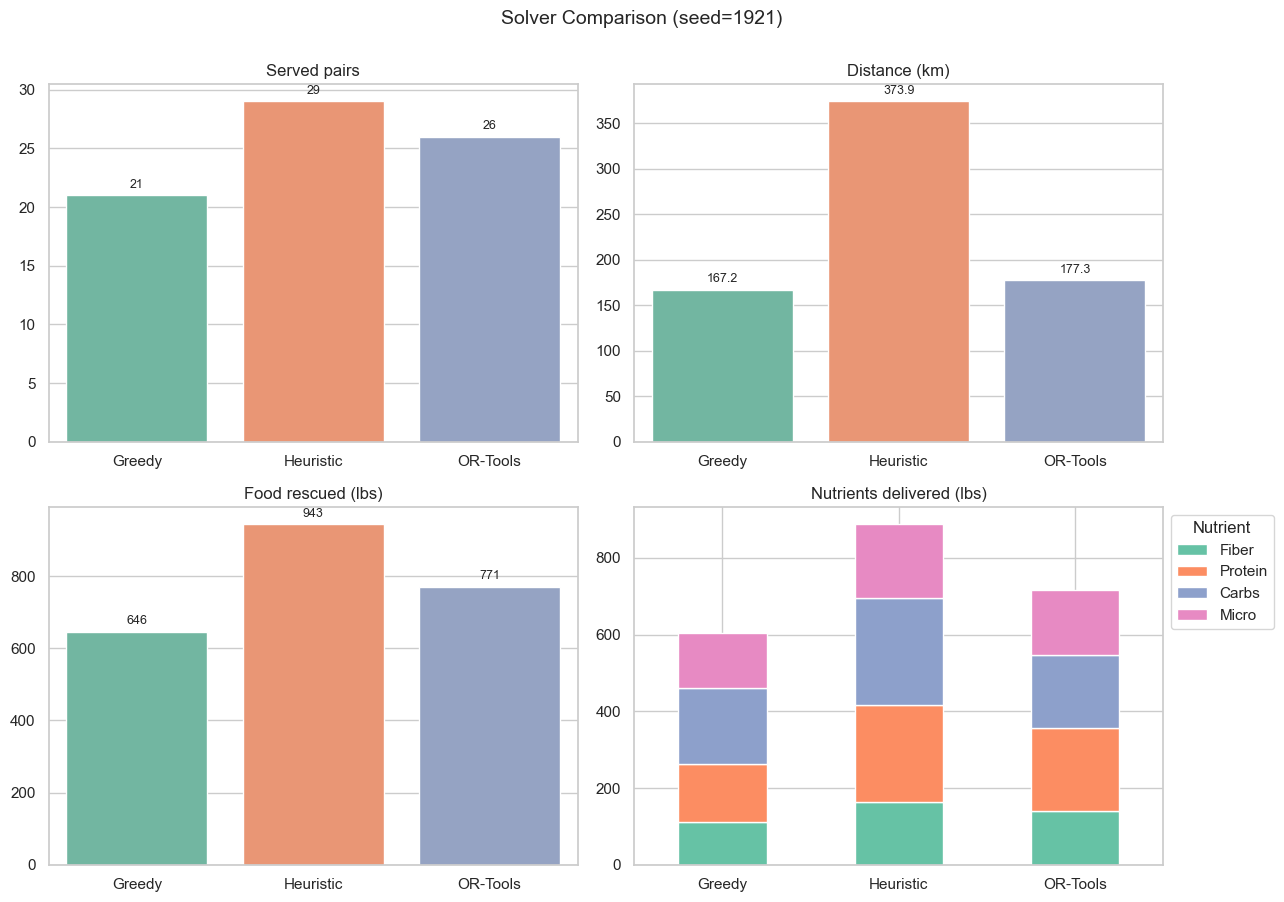


Summary:
Solver        Served   Dist(km)   Food(lbs)
-------------------------------------------
Greedy            21     167.17         646
Heuristic         29     373.89         943
OR-Tools          26     177.26         771


In [32]:
# Solver Comparison: greedy vs heuristic vs OR-Tools, plotted with seaborn.
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

# ---- Recompute OR-Tools metrics from solution / routing / manager ----
ortools_metrics = None
try:
    if solution is not None:
        served = 0
        for donor_v_node in range(1, nd):
            pickup_idx = manager.NodeToIndex(donor_v_node)
            delivery_idx = manager.NodeToIndex(nd + donor_v_node - 1)
            if pickup_idx == -1 or delivery_idx == -1:
                continue
            if (solution.Value(routing.ActiveVar(pickup_idx)) == 1
                    and solution.Value(routing.ActiveVar(delivery_idx)) == 1):
                served += 1

        total_distance = 0
        served_donors = []
        for vehicle_id in range(num_vehicles):
            idx = routing.Start(vehicle_id)
            while not routing.IsEnd(idx):
                v_node = manager.IndexToNode(idx)
                if 0 < v_node < nd:
                    served_donors.append(v_node)
                nxt = solution.Value(routing.NextVar(idx))
                total_distance += routing.GetArcCostForVehicle(idx, nxt, vehicle_id)
                idx = nxt

        food = sum(int(donor_total_weight[d]) for d in served_donors)
        nutrients = np.zeros(donor_nutrients.shape[1], dtype=np.int64)
        for d in served_donors:
            nutrients += donor_nutrients[d]

        ortools_metrics = {
            "served": served,
            "total_distance_m": int(total_distance),
            "food_lbs": int(food),
            "nutrients": nutrients,
        }
except NameError:
    ortools_metrics = None

solvers = []
solvers.append(("Greedy", {
    "served": int(sum(len(r) for r in greedy_routes)),
    "total_distance_m": int(greedy_total_distance),
    "food_lbs": int(greedy_total_food),
    "nutrients": greedy_nutrients_delivered.astype(np.int64),
}))
solvers.append(("Heuristic", {
    "served": int(heuristic_served),
    "total_distance_m": int(heuristic_total_distance),
    "food_lbs": int(heuristic_total_food),
    "nutrients": heuristic_nutrients_delivered.astype(np.int64),
}))
if ortools_metrics is not None:
    solvers.append(("OR-Tools", ortools_metrics))

order = [name for name, _ in solvers]

# ---- Long-format DataFrame for the three scalar metrics ----
scalar_rows = []
for name, m in solvers:
    scalar_rows.append({"solver": name, "metric": "Served pairs",       "value": float(m["served"])})
    scalar_rows.append({"solver": name, "metric": "Distance (km)",      "value": m["total_distance_m"] / 1000.0})
    scalar_rows.append({"solver": name, "metric": "Food rescued (lbs)", "value": float(m["food_lbs"])})
scalar_df = pd.DataFrame(scalar_rows)
print(scalar_df.to_string(index=False))

# ---- Stacked-nutrient DataFrame ----
nutrient_rows = []
for name, m in solvers:
    for nname, qty in zip(nutrient_names, m["nutrients"]):
        nutrient_rows.append({"solver": name, "nutrient": nname, "lbs": int(qty)})
nutrient_df = pd.DataFrame(nutrient_rows)

# ---- Plot ----
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
palette = sns.color_palette("Set2", n_colors=len(order))

for ax, metric in zip(axes.flat[:3], ["Served pairs", "Distance (km)", "Food rescued (lbs)"]):
    sub = scalar_df[scalar_df["metric"] == metric]
    sns.barplot(data=sub, x="solver", y="value", order=order,
                hue="solver", palette=palette, legend=False, ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylabel("")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f" if metric != "Distance (km)" else "%.1f",
                     padding=3, fontsize=9)

ax = axes.flat[3]
nut_pivot = (nutrient_df
             .pivot(index="solver", columns="nutrient", values="lbs")
             .reindex(order)[nutrient_names])
nut_pivot.plot(kind="bar", stacked=True, ax=ax,
               color=sns.color_palette("Set2", n_colors=len(nutrient_names)))
ax.set_title("Nutrients delivered (lbs)")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Nutrient", loc="upper left", bbox_to_anchor=(1.0, 1.0))

fig.suptitle("Solver Comparison (seed=1921)", fontsize=14, y=1.00)
fig.tight_layout()
plt.show()

# ---- Compact table ----
print("\nSummary:")
header = f"{'Solver':<12} {'Served':>7} {'Dist(km)':>10} {'Food(lbs)':>11}"
print(header)
print("-" * len(header))
for name, m in solvers:
    print(f"{name:<12} {m['served']:>7d} {m['total_distance_m']/1000:>10.2f} {m['food_lbs']:>11d}")


## Parameterized Experiments

Everything above runs on a single hard-coded instance (`seed=1921`, 50 donors,
14 pantries, 5 vehicles). To characterize the three solvers across the
parameter space — and answer the rubric's question of *why* each one performs
the way it does — we now:

1. Wrap the data generation in `make_instance(n_donors, n_pantries, n_vehicles, seed, ...)`,
   subsampling locations from the cached OSRM matrix and re-drawing all synthetic
   per-instance attributes (weights, nutrients, time windows, pantry capacities)
   under the supplied seed.
2. Wrap each solver in `solve_greedy / solve_heuristic / solve_ortools(instance, ...)`
   returning a common `SolverResult` (served, distance, food, nutrients,
   wall-clock, list of `(donor, pantry)` trips per vehicle, and the first
   binding constraint per unserved donor).
3. Add a "binding-constraint" diagnostic that, for every dropped donor in the
   greedy result, records which constraint (vehicle capacity, pantry capacity,
   per-nutrient cap, donor time window, spoilage clock, depot horizon, infeasible
   arc, no feasible pantry assigned, no-vehicle-fits) was the *first* to bite.
4. Sweep `n_donors ∈ {10, 20, 35, 50}` × `seeds ∈ {1921, 7, 42, 100, 314}` for
   all three solvers, store wall-clock + served + distance + food, and plot
   scaling curves with seed-error bands plus an efficiency view (lbs delivered
   per km, lbs per vehicle-hour) so the heuristic's distance cost is framed
   honestly.


In [33]:
# Common SolverResult container + parameterized instance generator.
from dataclasses import dataclass, field
from typing import Any

# Reasons recorded by the binding-constraint diagnostic.
BINDING_REASONS = (
    "vehicle_capacity",     # donor weight > any vehicle capacity
    "pantry_capacity",      # nearest-feasible pantry weight headroom exhausted
    "nutrient_cap",         # per-nutrient cap on nearest-feasible pantry exhausted
    "donor_time_window",    # cannot reach donor before donor_time_close
    "spoilage_clock",       # arrival at pantry > pickup + SPOILAGE_LIMIT
    "pantry_time_window",   # arrival at pantry > dropoff_time_close
    "depot_horizon",        # cannot return to depot before DEPOT_CLOSE
    "infeasible_arc",       # required arc has INFEASIBLE distance/duration
    "no_pantry_assigned",   # donor_to_pantry == -1 (no feasible pantry within crow-flies filter)
    "no_vehicle_fits",      # all vehicles full or no insertion ever feasible
)


@dataclass
class SolverResult:
    name: str
    instance_label: str
    served: int
    pairs_total: int
    total_distance_m: int
    food_lbs: int
    nutrients: np.ndarray
    wall_clock_s: float
    routes: list                                     # per-vehicle list of (donor, pantry_real_idx)
    binding_reason_counts: dict = field(default_factory=dict)
    extra: dict = field(default_factory=dict)


def make_instance(
    n_donors: int,
    n_pantries: int,
    n_vehicles: int,
    seed: int,
    *,
    vehicle_capacity: int = 200,
    nutrient_cap_fraction: float = 0.85,
    spoilage_limit_s: int = 7200,
    depot_close_s: int = 28800,
    full_route_matrix: dict = None,
) -> dict:
    """Subsample (n_donors-1 actual donors + 1 depot) + n_pantries from the cached
    OSRM matrix and re-draw all synthetic per-donor / per-pantry attributes from
    `seed`. n_donors counts the depot; effective donor count is n_donors - 1."""
    if full_route_matrix is None:
        full_route_matrix = route_matrix
    rng = np.random.default_rng(seed)
    full_nd = int(full_route_matrix["n_donors"])
    full_np = len(full_route_matrix["locations"]) - full_nd
    if n_donors > full_nd:
        raise ValueError(f"n_donors={n_donors} exceeds cached pool of {full_nd}")
    if n_pantries > full_np:
        raise ValueError(f"n_pantries={n_pantries} exceeds cached pool of {full_np}")

    # Always keep location 0 as the depot for parity with the in-place run above.
    donor_pool = rng.choice(np.arange(1, full_nd), size=n_donors - 1, replace=False)
    donor_idx = np.concatenate([[0], donor_pool])
    pantry_idx = full_nd + rng.choice(np.arange(full_np), size=n_pantries, replace=False)
    sel = np.concatenate([donor_idx, pantry_idx])

    distance = full_route_matrix["distance"][np.ix_(sel, sel)].astype(np.int64)
    duration = full_route_matrix["duration"][np.ix_(sel, sel)].astype(np.int64)
    locations = [full_route_matrix["locations"][int(i)] for i in sel]

    donor_total_weight = rng.integers(10, 60, size=n_donors).astype(np.int64)
    donor_total_weight[0] = 0
    proportions = rng.dirichlet(np.ones(4), size=n_donors)
    donor_nutrients = np.floor(donor_total_weight[:, None] * proportions).astype(np.int64)

    donor_time_open = rng.integers(0, 14400, size=n_donors).astype(np.int64)
    donor_time_open[0] = 0
    donor_time_close = donor_time_open + spoilage_limit_s
    donor_time_close[0] = depot_close_s

    dropoff_capacity = rng.integers(50, 200, size=n_pantries).astype(np.int64)
    dropoff_nutrient_max = np.floor(dropoff_capacity * nutrient_cap_fraction).astype(np.int64)
    dropoff_time_open = np.zeros(n_pantries, dtype=np.int64)
    dropoff_time_close = np.full(n_pantries, depot_close_s, dtype=np.int64)

    donor_to_pantry = np.full(n_donors, -1, dtype=int)
    for d in range(1, n_donors):
        d2p = distance[d, n_donors:]
        feasible = d2p < INFEASIBLE
        if feasible.any():
            donor_to_pantry[d] = int(np.argmin(np.where(feasible, d2p, np.inf)))

    return {
        "label": f"n{n_donors}_p{n_pantries}_v{n_vehicles}_s{seed}",
        "nd": n_donors,
        "n_pantries": n_pantries,
        "n_total": n_donors + n_pantries,
        "n_vehicles": n_vehicles,
        "vehicle_capacities": [vehicle_capacity] * n_vehicles,
        "depot_index": 0,
        "spoilage_limit_s": spoilage_limit_s,
        "depot_close_s": depot_close_s,
        "service_time_s": 600,
        "distance": distance,
        "duration": duration,
        "locations": locations,
        "donor_total_weight": donor_total_weight,
        "donor_nutrients": donor_nutrients,
        "donor_time_open": donor_time_open,
        "donor_time_close": donor_time_close,
        "dropoff_capacity": dropoff_capacity,
        "dropoff_nutrient_max": dropoff_nutrient_max,
        "dropoff_time_open": dropoff_time_open,
        "dropoff_time_close": dropoff_time_close,
        "donor_to_pantry": donor_to_pantry,
        "seed": seed,
    }


_smoke = make_instance(n_donors=10, n_pantries=5, n_vehicles=2, seed=7)
print(f"smoke: {_smoke['label']} | nd={_smoke['nd']} np={_smoke['n_pantries']} "
      f"vehicles={_smoke['n_vehicles']} | viable arcs={(_smoke['distance'] < INFEASIBLE).sum()}")


smoke: n10_p5_v2_s7 | nd=10 np=5 vehicles=2 | viable arcs=183


In [34]:
# solve_greedy: per-vehicle, single-pair trips, cheapest-incremental-distance.
# Records the first binding constraint for every donor it can't serve.
import time as _time


def _greedy_check(inst, d, p_local, curr, t, *, vehicle_id):
    """Return (feasible, reason_or_None, leg_distance, depart_pantry_time, p_real)."""
    nd_ = inst["nd"]
    p_real = nd_ + p_local
    w = int(inst["donor_total_weight"][d])
    if w > inst["vehicle_capacities"][vehicle_id]:
        return False, "vehicle_capacity", 0, 0, p_real

    dist = inst["distance"]; dur = inst["duration"]
    d_cd = int(dist[curr, d]);     t_cd = int(dur[curr, d])
    d_dp = int(dist[d, p_real]);   t_dp = int(dur[d, p_real])
    d_p0 = int(dist[p_real, 0]);   t_p0 = int(dur[p_real, 0])
    if max(d_cd, d_dp, d_p0) >= INFEASIBLE:
        return False, "infeasible_arc", 0, 0, p_real

    arrive_d = max(t + t_cd, int(inst["donor_time_open"][d]))
    if arrive_d > int(inst["donor_time_close"][d]):
        return False, "donor_time_window", 0, 0, p_real
    depart_d = arrive_d + inst["service_time_s"]
    arrive_p = depart_d + t_dp
    if arrive_p > arrive_d + inst["spoilage_limit_s"]:
        return False, "spoilage_clock", 0, 0, p_real
    if arrive_p > int(inst["dropoff_time_close"][p_local]):
        return False, "pantry_time_window", 0, 0, p_real
    depart_p = arrive_p + inst["service_time_s"]
    if depart_p + t_p0 > inst["depot_close_s"]:
        return False, "depot_horizon", 0, 0, p_real

    return True, None, d_cd + d_dp, depart_p, p_real


def solve_greedy(instance: dict) -> SolverResult:
    inst = instance
    nd_ = inst["nd"]
    num_vehicles = inst["n_vehicles"]
    num_pantries = inst["n_pantries"]
    depot_index = inst["depot_index"]
    nutrient_dim = inst["donor_nutrients"].shape[1]

    pantry_load_left = inst["dropoff_capacity"].astype(np.int64).copy()
    pantry_nut_left  = np.tile(inst["dropoff_nutrient_max"].reshape(-1, 1), (1, nutrient_dim)).astype(np.int64)

    unserved = set(range(1, nd_))
    routes = [[] for _ in range(num_vehicles)]
    total_distance = 0
    total_food = 0
    nutrients_delivered = np.zeros(nutrient_dim, dtype=np.int64)

    t0 = _time.perf_counter()
    for vehicle_id in range(num_vehicles):
        curr = depot_index
        t = 0
        route_distance = 0
        while True:
            best = None
            for d in unserved:
                p_local = int(inst["donor_to_pantry"][d])
                if p_local < 0:
                    continue
                if pantry_load_left[p_local] < int(inst["donor_total_weight"][d]):
                    continue
                if np.any(pantry_nut_left[p_local] < inst["donor_nutrients"][d]):
                    continue
                ok, _, leg_dist, depart_p, p_real = _greedy_check(inst, d, p_local, curr, t, vehicle_id=vehicle_id)
                if not ok:
                    continue
                cand = (leg_dist, d, p_local, p_real, depart_p)
                if best is None or cand < best:
                    best = cand
            if best is None:
                break
            leg_dist, d, p_local, p_real, depart_p = best
            w = int(inst["donor_total_weight"][d])
            route_distance += leg_dist
            unserved.discard(d)
            pantry_load_left[p_local] -= w
            pantry_nut_left[p_local]  -= inst["donor_nutrients"][d]
            total_food += w
            nutrients_delivered += inst["donor_nutrients"][d]
            curr = p_real
            t = depart_p
            routes[vehicle_id].append((d, p_real))
        if curr != depot_index:
            route_distance += int(inst["distance"][curr, depot_index])
        total_distance += route_distance
    wall = _time.perf_counter() - t0

    # Binding-constraint diagnostic for unserved donors.
    reason_priority = {r: i for i, r in enumerate(BINDING_REASONS)}
    binding_counts = {r: 0 for r in BINDING_REASONS}
    for d in unserved:
        p_local = int(inst["donor_to_pantry"][d])
        if p_local < 0:
            binding_counts["no_pantry_assigned"] += 1
            continue
        if pantry_load_left[p_local] < int(inst["donor_total_weight"][d]):
            binding_counts["pantry_capacity"] += 1
            continue
        if np.any(pantry_nut_left[p_local] < inst["donor_nutrients"][d]):
            binding_counts["nutrient_cap"] += 1
            continue
        # Simulate from depot, time=0, on every vehicle; pick the lowest-priority reason.
        best_reason = None
        for v in range(num_vehicles):
            ok, reason, *_ = _greedy_check(inst, d, p_local, depot_index, 0, vehicle_id=v)
            if ok:
                best_reason = "no_vehicle_fits"
                break
            if best_reason is None or reason_priority[reason] < reason_priority[best_reason]:
                best_reason = reason
        binding_counts[best_reason] += 1

    served = sum(len(r) for r in routes)
    return SolverResult(
        name="Greedy",
        instance_label=inst["label"],
        served=served,
        pairs_total=nd_ - 1,
        total_distance_m=int(total_distance),
        food_lbs=int(total_food),
        nutrients=nutrients_delivered,
        wall_clock_s=wall,
        routes=routes,
        binding_reason_counts=binding_counts,
    )


_r = solve_greedy(make_instance(10, 5, 2, seed=7))
print(f"greedy smoke: served={_r.served}/{_r.pairs_total} dist={_r.total_distance_m}m "
      f"food={_r.food_lbs}lbs wall={_r.wall_clock_s*1000:.1f}ms")
print("  binding:", {k: v for k, v in _r.binding_reason_counts.items() if v})


greedy smoke: served=4/9 dist=36703m food=137lbs wall=0.2ms
  binding: {'pantry_capacity': 4, 'infeasible_arc': 1}


In [35]:
# solve_heuristic: regret-2 insertion + free pantry + chained trips + intra-route 2-opt.
from itertools import permutations


def solve_heuristic(instance: dict) -> SolverResult:
    inst = instance
    nd_ = inst["nd"]
    num_vehicles = inst["n_vehicles"]
    num_pantries = inst["n_pantries"]
    depot_index = inst["depot_index"]
    nutrient_dim = inst["donor_nutrients"].shape[1]
    SERVICE_TIME = inst["service_time_s"]
    DEPOT_CLOSE = inst["depot_close_s"]
    SPOIL = inst["spoilage_limit_s"]
    dist = inst["distance"]; dur = inst["duration"]

    pantry_load_left = inst["dropoff_capacity"].astype(np.int64).copy()
    pantry_nut_left  = np.tile(inst["dropoff_nutrient_max"].reshape(-1, 1), (1, nutrient_dim)).astype(np.int64)

    routes = [{"trips": [], "last_loc": depot_index, "last_time": 0, "dist_no_return": 0}
              for _ in range(num_vehicles)]

    def trip_eval(state, vehicle_id, d, p_local):
        w = int(inst["donor_total_weight"][d])
        if w > inst["vehicle_capacities"][vehicle_id]:
            return None
        if pantry_load_left[p_local] < w:
            return None
        if np.any(pantry_nut_left[p_local] < inst["donor_nutrients"][d]):
            return None
        p_real = nd_ + p_local
        cur = state["last_loc"]; t = state["last_time"]
        d_cd = int(dist[cur, d]);     t_cd = int(dur[cur, d])
        d_dp = int(dist[d, p_real]);  t_dp = int(dur[d, p_real])
        d_p0 = int(dist[p_real, depot_index]); t_p0 = int(dur[p_real, depot_index])
        if max(d_cd, d_dp, d_p0) >= INFEASIBLE:
            return None
        arrive_d = max(t + t_cd, int(inst["donor_time_open"][d]))
        if arrive_d > int(inst["donor_time_close"][d]):
            return None
        depart_d = arrive_d + SERVICE_TIME
        arrive_p = depart_d + t_dp
        if arrive_p > arrive_d + SPOIL:
            return None
        if arrive_p > int(inst["dropoff_time_close"][p_local]):
            return None
        depart_p = arrive_p + SERVICE_TIME
        if depart_p + t_p0 > DEPOT_CLOSE:
            return None
        old_return = int(dist[cur, depot_index]) if state["trips"] else 0
        new_return = d_p0
        delta = (d_cd + d_dp + new_return) - old_return
        return (delta, p_real, depart_p, state["dist_no_return"] + d_cd + d_dp)

    def best_pantry_for(d, vehicle_id, state):
        best = None
        for p_local in range(num_pantries):
            ev = trip_eval(state, vehicle_id, d, p_local)
            if ev is None:
                continue
            delta, p_real, depart_t, dnr = ev
            cand = (delta, p_local, p_real, depart_t, dnr)
            if best is None or cand[0] < best[0]:
                best = cand
        return best

    t0 = _time.perf_counter()
    unserved = set(range(1, nd_))
    while unserved:
        per_donor = {}
        for d in unserved:
            opts = []
            for v in range(num_vehicles):
                bp = best_pantry_for(d, v, routes[v])
                if bp is None:
                    continue
                delta, p_local, p_real, depart_t, dnr = bp
                opts.append((delta, v, p_local, p_real, depart_t, dnr))
            if opts:
                opts.sort()
                per_donor[d] = opts
        if not per_donor:
            break
        def regret(d):
            opts = per_donor[d]
            return float("inf") if len(opts) == 1 else opts[1][0] - opts[0][0]
        pick_d = max(per_donor, key=regret)
        delta, v, p_local, p_real, depart_t, dnr = per_donor[pick_d][0]
        st = routes[v]
        st["trips"].append((pick_d, p_local))
        st["last_loc"] = p_real
        st["last_time"] = depart_t
        st["dist_no_return"] = dnr
        pantry_load_left[p_local] -= int(inst["donor_total_weight"][pick_d])
        pantry_nut_left[p_local]  -= inst["donor_nutrients"][pick_d]
        unserved.discard(pick_d)

    def route_total_if_feasible(trips):
        cur = depot_index; t = 0; total = 0
        for (d, p_local) in trips:
            p_real = nd_ + p_local
            d_cd = int(dist[cur, d]);     t_cd = int(dur[cur, d])
            d_dp = int(dist[d, p_real]);  t_dp = int(dur[d, p_real])
            if max(d_cd, d_dp) >= INFEASIBLE:
                return None
            arrive_d = max(t + t_cd, int(inst["donor_time_open"][d]))
            if arrive_d > int(inst["donor_time_close"][d]):
                return None
            depart_d = arrive_d + SERVICE_TIME
            arrive_p = depart_d + t_dp
            if arrive_p > arrive_d + SPOIL:
                return None
            if arrive_p > int(inst["dropoff_time_close"][p_local]):
                return None
            t = arrive_p + SERVICE_TIME
            total += d_cd + d_dp
            cur = p_real
        if cur != depot_index:
            d_back = int(dist[cur, depot_index]); t_back = int(dur[cur, depot_index])
            if d_back >= INFEASIBLE or t + t_back > DEPOT_CLOSE:
                return None
            total += d_back
        return total

    for st in routes:
        trips = st["trips"]
        if len(trips) <= 1:
            continue
        base = route_total_if_feasible(trips)
        best_trips, best_cost = trips, base
        if len(trips) <= 7:
            for perm in permutations(trips):
                if perm == tuple(trips):
                    continue
                c = route_total_if_feasible(list(perm))
                if c is not None and c < best_cost:
                    best_trips, best_cost = list(perm), c
        else:
            improved = True
            cur_trips, cur_cost = list(trips), base
            while improved:
                improved = False
                for i in range(len(cur_trips)):
                    for j in range(i + 1, len(cur_trips)):
                        cand = list(cur_trips)
                        cand[i], cand[j] = cand[j], cand[i]
                        c = route_total_if_feasible(cand)
                        if c is not None and c < cur_cost:
                            cur_trips, cur_cost, improved = cand, c, True
            best_trips, best_cost = cur_trips, cur_cost
        st["trips"] = best_trips
        st["dist_no_return"] = best_cost - (int(dist[nd_ + best_trips[-1][1], depot_index]) if best_trips else 0)
    wall = _time.perf_counter() - t0

    routes_out = [[(d, nd_ + p_local) for (d, p_local) in st["trips"]] for st in routes]
    total_distance = sum(
        st["dist_no_return"] + (int(dist[st["last_loc"], depot_index]) if st["trips"] else 0)
        for st in routes
    )
    total_food = sum(int(inst["donor_total_weight"][d]) for r in routes_out for (d, _) in r)
    nutrients_delivered = np.zeros(nutrient_dim, dtype=np.int64)
    for r in routes_out:
        for (d, _) in r:
            nutrients_delivered += inst["donor_nutrients"][d]
    served = sum(len(r) for r in routes_out)

    return SolverResult(
        name="Heuristic",
        instance_label=inst["label"],
        served=served,
        pairs_total=nd_ - 1,
        total_distance_m=int(total_distance),
        food_lbs=int(total_food),
        nutrients=nutrients_delivered,
        wall_clock_s=wall,
        routes=routes_out,
    )


_r = solve_heuristic(make_instance(10, 5, 2, seed=7))
print(f"heuristic smoke: served={_r.served}/{_r.pairs_total} dist={_r.total_distance_m}m "
      f"food={_r.food_lbs}lbs wall={_r.wall_clock_s*1000:.1f}ms")


heuristic smoke: served=8/9 dist=117471m food=319lbs wall=4.8ms


In [36]:
# solve_ortools: CP / Routing model with the same constraints as the in-place run above,
# but with the spoilage-clock indentation bug fixed (constraint added per donor pair).
from ortools.constraint_solver import routing_enums_pb2, pywrapcp




def solve_ortools(instance: dict, *, time_limit_s: int = 10) -> SolverResult:
    inst = instance
    nd_ = inst["nd"]
    num_vehicles = inst["n_vehicles"]
    num_pantries = inst["n_pantries"]
    depot_index = inst["depot_index"]
    nutrient_dim = inst["donor_nutrients"].shape[1]
    SERVICE_TIME = inst["service_time_s"]
    DEPOT_CLOSE = inst["depot_close_s"]
    SPOIL = inst["spoilage_limit_s"]
    dist = inst["distance"]; dur = inst["duration"]
    donor_to_pantry = inst["donor_to_pantry"]

    total_virtual_nodes = 2 * nd_ - 1

    def get_real_node(v_node):
        if v_node < nd_:
            return v_node
        donor_idx = v_node - nd_ + 1
        p_local = int(donor_to_pantry[donor_idx])
        if p_local < 0:
            return nd_
        return nd_ + p_local

    manager = pywrapcp.RoutingIndexManager(total_virtual_nodes, num_vehicles, depot_index)
    routing = pywrapcp.RoutingModel(manager)
    cb_store = []

    def distance_cb(from_idx, to_idx):
        try:
            f = get_real_node(manager.IndexToNode(from_idx))
            t = get_real_node(manager.IndexToNode(to_idx))
            v = float(dist[f][t])
            if np.isnan(v) or np.isinf(v) or v > 999999:
                return 999999
            return int(v)
        except Exception:
            return 999999

    cb_store.append(distance_cb)
    transit_cb = routing.RegisterTransitCallback(distance_cb)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_cb)

    def time_cb(from_idx, to_idx):
        try:
            f = get_real_node(manager.IndexToNode(from_idx))
            t = get_real_node(manager.IndexToNode(to_idx))
            v = float(dur[f][t])
            if np.isnan(v) or np.isinf(v) or v > 999999:
                return 999999
            return int(v + (SERVICE_TIME if f != depot_index else 0))
        except Exception:
            return 999999

    cb_store.append(time_cb)
    time_cb_idx = routing.RegisterTransitCallback(time_cb)
    routing.AddDimension(time_cb_idx, DEPOT_CLOSE, DEPOT_CLOSE, False, "Time")
    time_dim = routing.GetDimensionOrDie("Time")

    time_windows = [(int(o), int(c)) for o, c in zip(
        np.concatenate([inst["donor_time_open"], inst["dropoff_time_open"]]),
        np.concatenate([inst["donor_time_close"], inst["dropoff_time_close"]]),
    )]
    for v_node in range(total_virtual_nodes):
        if v_node == 0:
            continue
        idx = manager.NodeToIndex(v_node)
        if idx == -1:
            continue
        real_node = get_real_node(v_node)
        t_open, t_close = time_windows[real_node]
        tv = time_dim.CumulVar(idx)
        if tv is not None:
            tv.SetRange(int(t_open), int(t_close))

    depot_open, depot_close = time_windows[depot_index]
    for veh in range(num_vehicles):
        for end in (routing.Start(veh), routing.End(veh)):
            v = time_dim.CumulVar(end)
            if v is not None:
                v.SetRange(int(depot_open), int(depot_close))

    def demand_cb(from_idx):
        try:
            v_node = manager.IndexToNode(from_idx)
            if v_node == 0:
                return 0
            if v_node < nd_:
                return int(inst["donor_total_weight"][v_node])
            return -int(inst["donor_total_weight"][v_node - nd_ + 1])
        except Exception:
            return 0

    cb_store.append(demand_cb)
    demand_cb_idx = routing.RegisterUnaryTransitCallback(demand_cb)
    routing.AddDimensionWithVehicleCapacity(
        demand_cb_idx, 0, inst["vehicle_capacities"], True, "Weight",
    )

    PER_NODE_DROP_PENALTY = 1_000_000
    for donor_v_node in range(1, nd_):
        dropoff_v_node = nd_ + donor_v_node - 1
        pickup_idx = manager.NodeToIndex(donor_v_node)
        delivery_idx = manager.NodeToIndex(dropoff_v_node)
        if pickup_idx == -1 or delivery_idx == -1:
            continue
        routing.AddDisjunction([pickup_idx], PER_NODE_DROP_PENALTY)
        routing.AddDisjunction([delivery_idx], PER_NODE_DROP_PENALTY)
        routing.AddPickupAndDelivery(pickup_idx, delivery_idx)
        routing.solver().Add(routing.VehicleVar(pickup_idx) == routing.VehicleVar(delivery_idx))
        routing.solver().Add(routing.ActiveVar(pickup_idx) == routing.ActiveVar(delivery_idx))
        routing.solver().Add(time_dim.CumulVar(pickup_idx) <= time_dim.CumulVar(delivery_idx))
        # Spoilage clock: per pair (this is the bug fix).
        routing.solver().Add(time_dim.CumulVar(delivery_idx) <= time_dim.CumulVar(pickup_idx) + SPOIL)

    solver = routing.solver()
    donors_for_pantry = {p: [] for p in range(num_pantries)}
    for d in range(1, nd_):
        p_local = int(donor_to_pantry[d])
        if p_local >= 0:
            donors_for_pantry[p_local].append(d)
    for p_local, donors in donors_for_pantry.items():
        if not donors:
            continue
        for k in range(nutrient_dim):
            solver.Add(
                solver.Sum([
                    routing.ActiveVar(manager.NodeToIndex(d)) * int(inst["donor_nutrients"][d][k])
                    for d in donors
                ]) <= int(inst["dropoff_nutrient_max"][p_local])
            )
        solver.Add(
            solver.Sum([
                routing.ActiveVar(manager.NodeToIndex(d)) * int(inst["donor_total_weight"][d])
                for d in donors
            ]) <= int(inst["dropoff_capacity"][p_local])
        )

    sp = pywrapcp.DefaultRoutingSearchParameters()
    sp.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PARALLEL_CHEAPEST_INSERTION
    sp.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    sp.time_limit.seconds = int(time_limit_s)

    t0 = _time.perf_counter()
    solution = routing.SolveWithParameters(sp)
    wall = _time.perf_counter() - t0

    routes_out = [[] for _ in range(num_vehicles)]
    total_distance = 0
    total_food = 0
    nutrients_delivered = np.zeros(nutrient_dim, dtype=np.int64)
    served = 0

    if solution is not None:
        for veh in range(num_vehicles):
            idx = routing.Start(veh)
            curr_donor = None
            while not routing.IsEnd(idx):
                v_node = manager.IndexToNode(idx)
                if 0 < v_node < nd_:
                    curr_donor = v_node
                elif v_node >= nd_ and curr_donor is not None:
                    p_real = get_real_node(v_node)
                    routes_out[veh].append((curr_donor, p_real))
                    total_food += int(inst["donor_total_weight"][curr_donor])
                    nutrients_delivered += inst["donor_nutrients"][curr_donor]
                    served += 1
                    curr_donor = None
                nxt = solution.Value(routing.NextVar(idx))
                total_distance += routing.GetArcCostForVehicle(idx, nxt, veh)
                idx = nxt

    return SolverResult(
        name="OR-Tools",
        instance_label=inst["label"],
        served=served,
        pairs_total=nd_ - 1,
        total_distance_m=int(total_distance),
        food_lbs=int(total_food),
        nutrients=nutrients_delivered,
        wall_clock_s=wall,
        routes=routes_out,
        extra={"status": int(routing.status())},
    )


_r = solve_ortools(make_instance(10, 5, 2, seed=7), time_limit_s=5)
print(f"ortools smoke: served={_r.served}/{_r.pairs_total} dist={_r.total_distance_m}m "
      f"food={_r.food_lbs}lbs wall={_r.wall_clock_s:.2f}s status={_r.extra['status']}")


ortools smoke: served=4/9 dist=49058m food=139lbs wall=5.00s status=1


### Scaling sweep

We run all three solvers across `n_donors ∈ {10, 20, 35, 50}` (with the
pantry pool grown proportionally to keep ~3.5 donors / pantry, mirroring
the original 50/14 instance) and seeds `{1921, 7, 42, 100, 314}`. For
every cell we record `served`, `total_distance_m`, `food_lbs`, and
`wall_clock_s`. The OR-Tools solver gets a 10-second per-instance time
limit so the whole sweep finishes in a few minutes.


In [37]:
# Scaling sweep across (n_donors, seed) for all three solvers.
import pandas as pd

SWEEP_DONOR_SIZES = [10, 20, 35, 50]
SWEEP_SEEDS = [1921, 7, 42, 100, 314]
SWEEP_NUM_VEHICLES = 5
ORTOOLS_TIME_LIMIT_S = 10

def _pantries_for(n_donors):
    # Match the original 50d/14p ratio (~3.57 donors/pantry), capped at 14 (cached pool).
    return min(14, max(4, round(n_donors / 3.57)))

sweep_rows = []
for nd_i in SWEEP_DONOR_SIZES:
    np_i = _pantries_for(nd_i)
    for sd in SWEEP_SEEDS:
        inst = make_instance(nd_i, np_i, SWEEP_NUM_VEHICLES, sd)
        for solver_fn in (solve_greedy, solve_heuristic, solve_ortools):
            kwargs = {"time_limit_s": ORTOOLS_TIME_LIMIT_S} if solver_fn is solve_ortools else {}
            res = solver_fn(inst, **kwargs)
            sweep_rows.append({
                "solver": res.name,
                "n_donors": nd_i,
                "n_pantries": np_i,
                "seed": sd,
                "served": res.served,
                "pairs_total": res.pairs_total,
                "served_frac": res.served / max(res.pairs_total, 1),
                "distance_km": res.total_distance_m / 1000.0,
                "food_lbs": res.food_lbs,
                "wall_clock_s": res.wall_clock_s,
                "lbs_per_km": (res.food_lbs / (res.total_distance_m / 1000.0)) if res.total_distance_m > 0 else 0.0,
                "lbs_per_vehicle_hour": (res.food_lbs / (SWEEP_NUM_VEHICLES * (inst["depot_close_s"] / 3600.0))),
            })
            print(f"  {res.name:<10} n={nd_i:>2} seed={sd:>4} served={res.served:>2}/{res.pairs_total:<2} "
                  f"dist={res.total_distance_m/1000:>6.2f}km food={res.food_lbs:>4}lbs wall={res.wall_clock_s:>6.2f}s")

sweep_df = pd.DataFrame(sweep_rows)
print()
print(sweep_df.groupby(["solver", "n_donors"])[["served_frac", "distance_km", "food_lbs", "wall_clock_s"]].mean().round(2))


  Greedy     n=10 seed=1921 served= 5/9  dist= 78.99km food= 180lbs wall=  0.00s
  Heuristic  n=10 seed=1921 served= 7/9  dist=133.38km food= 266lbs wall=  0.01s
  OR-Tools   n=10 seed=1921 served= 4/9  dist= 82.78km food= 122lbs wall= 10.00s
  Greedy     n=10 seed=   7 served= 4/9  dist= 44.14km food= 194lbs wall=  0.00s
  Heuristic  n=10 seed=   7 served= 8/9  dist=112.99km food= 319lbs wall=  0.01s
  OR-Tools   n=10 seed=   7 served= 2/9  dist= 37.23km food=  98lbs wall= 10.00s
  Greedy     n=10 seed=  42 served= 5/9  dist= 57.24km food= 165lbs wall=  0.00s
  Heuristic  n=10 seed=  42 served= 7/9  dist=105.11km food= 227lbs wall=  0.01s
  OR-Tools   n=10 seed=  42 served= 4/9  dist= 78.05km food= 104lbs wall= 10.00s
  Greedy     n=10 seed= 100 served= 4/9  dist= 72.56km food= 133lbs wall=  0.00s
  Heuristic  n=10 seed= 100 served= 4/9  dist= 59.27km food= 143lbs wall=  0.00s
  OR-Tools   n=10 seed= 100 served= 2/9  dist= 65.49km food=  89lbs wall= 10.00s
  Greedy     n=10 seed= 314 

### Binding-constraint diagnostic

For every donor the greedy fails to serve in the largest sweep instance,
record which constraint bit *first* (vehicle capacity, pantry capacity,
nutrient cap, donor / pantry time window, spoilage clock, depot horizon,
infeasible arc, no feasible pantry assigned, or no vehicle-room left).
Aggregated across the seed pool, this turns "dropped 28/49" into an
actionable breakdown.


In [38]:
binding_rows = []
for sd in SWEEP_SEEDS:
    inst = make_instance(50, _pantries_for(50), SWEEP_NUM_VEHICLES, sd)
    res = solve_greedy(inst)
    for reason, count in res.binding_reason_counts.items():
        if count == 0:
            continue
        binding_rows.append({"seed": sd, "reason": reason, "count": count})

binding_df = pd.DataFrame(binding_rows)
binding_summary = (binding_df
                   .groupby("reason")["count"]
                   .agg(["sum", "mean"])
                   .sort_values("sum", ascending=False)
                   .rename(columns={"sum": "total_dropped", "mean": "avg_per_seed"}))
print("Binding constraints across the greedy at n_donors=50, vehicles=5, 5 seeds:")
print(binding_summary.round(2))


Binding constraints across the greedy at n_donors=50, vehicles=5, 5 seeds:
                    total_dropped  avg_per_seed
reason                                         
pantry_capacity                86          17.2
infeasible_arc                 43           8.6
no_pantry_assigned              5           1.0


### Scaling + efficiency plots

Two rows of comparison plots:

1. **Performance vs. instance size** — served fraction, total distance, wall-clock.
   Lines = mean across seeds; shaded bands = ±1 standard deviation.
2. **Efficiency** — lbs delivered per kilometer driven, lbs per
   vehicle-hour (8 h × 5 vehicles = 40 vehicle-hours), and a horizontal
   bar chart of the binding constraint that dropped each donor in the
   greedy at `n_donors=50`. The efficiency view frames the heuristic's
   distance cost honestly — it delivers more food than greedy, but
   spends more km doing it.


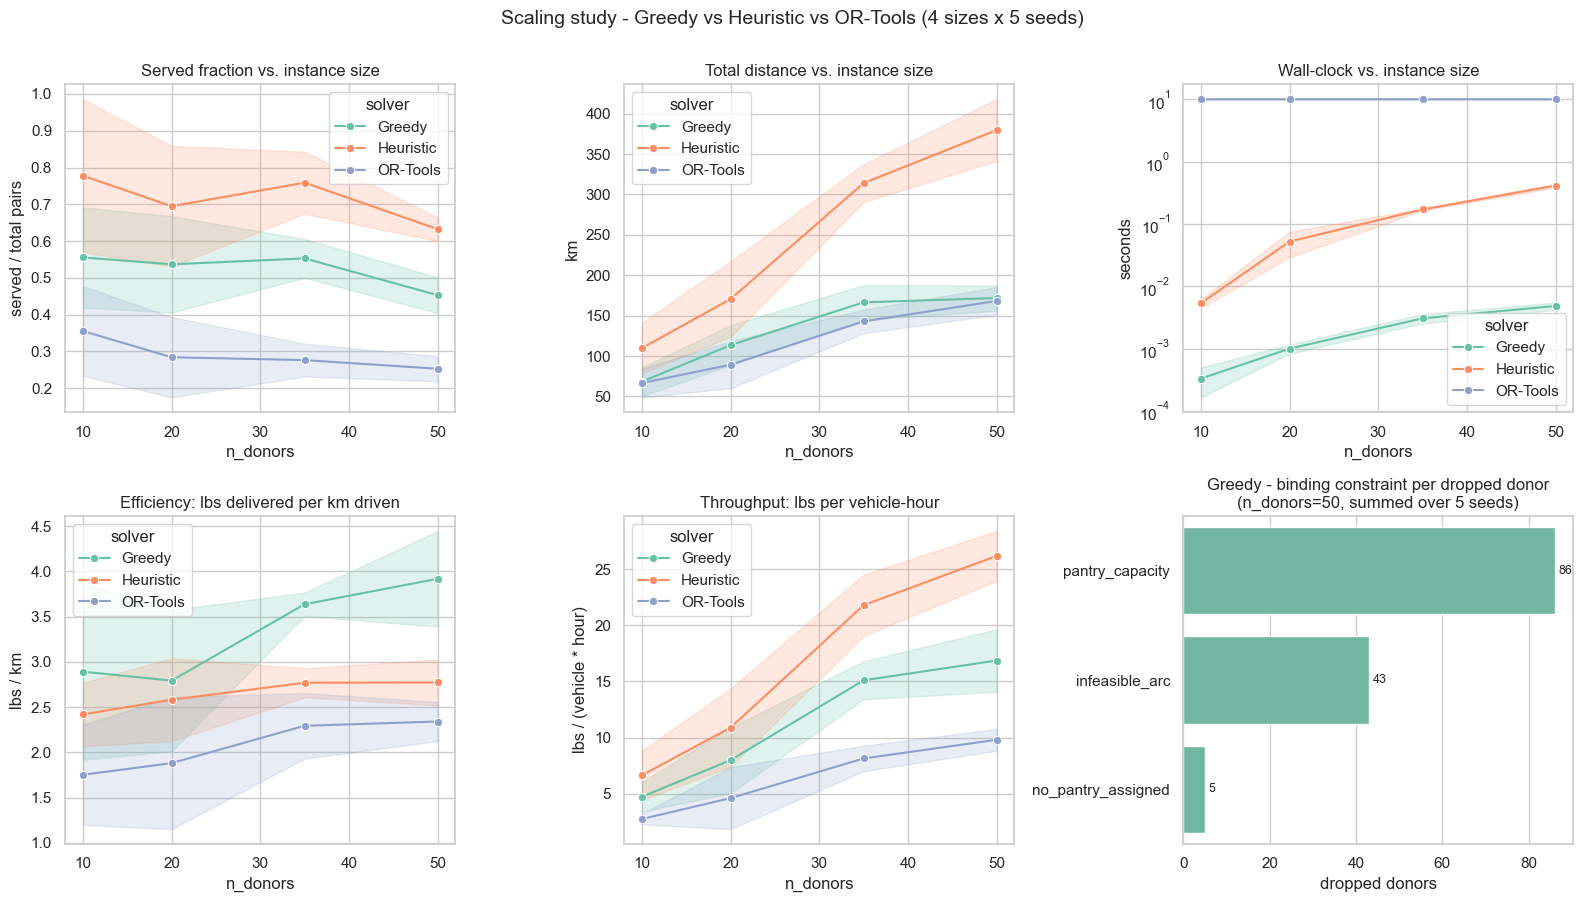

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
solver_order = ["Greedy", "Heuristic", "OR-Tools"]
palette = dict(zip(solver_order, sns.color_palette("Set2", n_colors=3)))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, (col, title, ylabel) in zip(
    axes[0],
    [
        ("served_frac", "Served fraction vs. instance size", "served / total pairs"),
        ("distance_km", "Total distance vs. instance size", "km"),
        ("wall_clock_s", "Wall-clock vs. instance size", "seconds"),
    ],
):
    sns.lineplot(
        data=sweep_df, x="n_donors", y=col, hue="solver", hue_order=solver_order,
        palette=palette, marker="o", errorbar="sd", ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("n_donors")
    ax.set_ylabel(ylabel)
    if col == "wall_clock_s":
        ax.set_yscale("log")

for ax, (col, title, ylabel) in zip(
    axes[1, :2],
    [
        ("lbs_per_km", "Efficiency: lbs delivered per km driven", "lbs / km"),
        ("lbs_per_vehicle_hour", "Throughput: lbs per vehicle-hour", "lbs / (vehicle * hour)"),
    ],
):
    sns.lineplot(
        data=sweep_df, x="n_donors", y=col, hue="solver", hue_order=solver_order,
        palette=palette, marker="o", errorbar="sd", ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("n_donors")
    ax.set_ylabel(ylabel)

ax = axes[1, 2]
if not binding_summary.empty:
    sns.barplot(
        x=binding_summary["total_dropped"].values,
        y=binding_summary.index.tolist(),
        color=palette["Greedy"], ax=ax,
    )
    ax.set_title("Greedy - binding constraint per dropped donor\n(n_donors=50, summed over 5 seeds)")
    ax.set_xlabel("dropped donors")
    ax.set_ylabel("")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)
else:
    ax.text(0.5, 0.5, "no dropped donors", ha="center", va="center")
    ax.set_axis_off()

fig.suptitle("Scaling study - Greedy vs Heuristic vs OR-Tools (4 sizes x 5 seeds)", fontsize=14, y=1.00)
fig.tight_layout()
plt.show()


### User-configurable constraints

The cell below is the project's **interactive knob panel**. Edit the
constants at the top to change vehicle capacity, the per-pantry
nutrient cap, the spoilage window, the depot horizon, the instance
size, or the random seed; then re-run the cell to see how each solver
responds. This is the same `make_instance` generator used by the
scaling sweep above, exposed as a one-cell sandbox so a reader can
explore the constraint trade-offs without editing the rest of the
notebook.


In [40]:
# === USER-CONFIGURABLE CONSTRAINTS =========================================
# Edit these knobs and re-run the cell.

USER_N_DONORS            = 50      # how many donors to sample (<= 50)
USER_N_PANTRIES          = 14      # how many pantries to sample (<= 14)
USER_N_VEHICLES          = 5       # fleet size
USER_SEED                = 1921    # RNG seed for the instance

USER_VEHICLE_CAPACITY    = 200     # lbs per vehicle
USER_NUTRIENT_CAP_FRAC   = 0.85    # fraction of pantry capacity reserved per nutrient
USER_SPOILAGE_LIMIT_S    = 7200    # seconds between pickup and drop-off (default = 2 h)
USER_DEPOT_CLOSE_S       = 28800   # seconds the depot stays open (default = 8 h)
USER_ORTOOLS_TIME_LIMIT  = 10      # OR-Tools wall-clock budget per solve (s)
# ===========================================================================

import time as _t

_user_inst = make_instance(
    n_donors=USER_N_DONORS,
    n_pantries=USER_N_PANTRIES,
    n_vehicles=USER_N_VEHICLES,
    seed=USER_SEED,
    vehicle_capacity=USER_VEHICLE_CAPACITY,
    nutrient_cap_fraction=USER_NUTRIENT_CAP_FRAC,
    spoilage_limit_s=USER_SPOILAGE_LIMIT_S,
    depot_close_s=USER_DEPOT_CLOSE_S,
)

print(f"Instance: {_user_inst['label']}")
print(f"  vehicle_capacity     = {USER_VEHICLE_CAPACITY} lbs")
print(f"  nutrient_cap_frac    = {USER_NUTRIENT_CAP_FRAC}")
print(f"  spoilage_limit_s     = {USER_SPOILAGE_LIMIT_S} s")
print(f"  depot_close_s        = {USER_DEPOT_CLOSE_S} s")
print(f"  pairs to schedule    = {_user_inst['nd'] - 1}")
print()

_user_results = [
    solve_greedy(_user_inst),
    solve_heuristic(_user_inst),
    solve_ortools(_user_inst, time_limit_s=USER_ORTOOLS_TIME_LIMIT),
]

print(f"{'solver':<12}{'served':>10}{'food_lbs':>12}{'dist_km':>12}{'wall_s':>10}")
print("-" * 56)
for r in _user_results:
    print(
        f"{r.name:<12}"
        f"{r.served:>4}/{r.pairs_total:<5}"
        f"{r.food_lbs:>12}"
        f"{r.total_distance_m / 1000:>12.1f}"
        f"{r.wall_clock_s:>10.3f}"
    )


Instance: n50_p14_v5_s1921
  vehicle_capacity     = 200 lbs
  nutrient_cap_frac    = 0.85
  spoilage_limit_s     = 7200 s
  depot_close_s        = 28800 s
  pairs to schedule    = 49

solver          served    food_lbs     dist_km    wall_s
--------------------------------------------------------
Greedy        23/49            728       188.2     0.005
Heuristic     29/49           1000       317.1     0.441
OR-Tools      15/49            446       175.1    10.000
